### Handwritten Digit Recognition using Deep Learning

In [1]:
# Import required libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score, classification_report
from sklearn import datasets

In [2]:
# Step 1: Load the Handwritten Digits Dataset
digits = datasets.load_digits()
X = digits.images  # 8x8 grayscale images
y = digits.target  # Labels (0 to 9)

In [5]:
# Step 2: Print dataset details
print("Dataset Shape:", X.shape)  # (1797, 8, 8)
print("Unique Labels:", np.unique(y))  # Labels: 0 to 9
print("\nSample Data:\n", X[:5])  # Print first 5 images as arrays
print("\nSample Labels:\n", y[:5])  # Print first 5 labels

Dataset Shape: (1797, 8, 8)
Unique Labels: [0 1 2 3 4 5 6 7 8 9]

Sample Data:
 [[[ 0.  0.  5. 13.  9.  1.  0.  0.]
  [ 0.  0. 13. 15. 10. 15.  5.  0.]
  [ 0.  3. 15.  2.  0. 11.  8.  0.]
  [ 0.  4. 12.  0.  0.  8.  8.  0.]
  [ 0.  5.  8.  0.  0.  9.  8.  0.]
  [ 0.  4. 11.  0.  1. 12.  7.  0.]
  [ 0.  2. 14.  5. 10. 12.  0.  0.]
  [ 0.  0.  6. 13. 10.  0.  0.  0.]]

 [[ 0.  0.  0. 12. 13.  5.  0.  0.]
  [ 0.  0.  0. 11. 16.  9.  0.  0.]
  [ 0.  0.  3. 15. 16.  6.  0.  0.]
  [ 0.  7. 15. 16. 16.  2.  0.  0.]
  [ 0.  0.  1. 16. 16.  3.  0.  0.]
  [ 0.  0.  1. 16. 16.  6.  0.  0.]
  [ 0.  0.  1. 16. 16.  6.  0.  0.]
  [ 0.  0.  0. 11. 16. 10.  0.  0.]]

 [[ 0.  0.  0.  4. 15. 12.  0.  0.]
  [ 0.  0.  3. 16. 15. 14.  0.  0.]
  [ 0.  0.  8. 13.  8. 16.  0.  0.]
  [ 0.  0.  1.  6. 15. 11.  0.  0.]
  [ 0.  1.  8. 13. 15.  1.  0.  0.]
  [ 0.  9. 16. 16.  5.  0.  0.  0.]
  [ 0.  3. 13. 16. 16. 11.  5.  0.]
  [ 0.  0.  0.  3. 11. 16.  9.  0.]]

 [[ 0.  0.  7. 15. 13.  1.  0.  0.]
  [ 0.  8. 13.

In [6]:
# Print dataset information
print("Dataset Shape:", digits.images.shape)  # (1797, 8, 8)
print("Number of Labels:", len(np.unique(digits.target)))  # 10 (0-9)

Dataset Shape: (1797, 8, 8)
Number of Labels: 10


In [7]:
# Step 3: Normalize Pixel Values
X = X / 16.0  # Normalize pixels (originally between 0-16)

# Step 4: Reshape Images for CNN
X = X.reshape(-1, 8, 8, 1)  # CNNs require (samples, height, width, channels)

# Step 5: Split into Training & Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

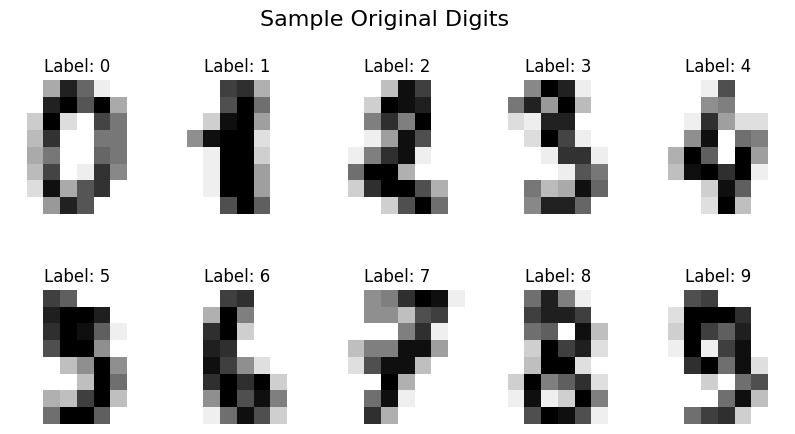

In [8]:
# Step 6: Convert Labels to One-Hot Encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

# Step 7: Visualize Original Digits
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')
plt.suptitle("Sample Original Digits", fontsize=16)
plt.show()

In [9]:
# Step 8: Define the CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(8,8,1)),  # Conv Layer
    layers.MaxPooling2D((2,2)),  # Max Pooling
    layers.Flatten(),  # Flatten for Fully Connected Layer
    layers.Dense(64, activation='relu'),  # Dense Layer
    layers.Dense(10, activation='softmax')  # Output Layer (10 Classes)
])


In [10]:
# Step 9: Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Step 10: Train the Model
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test), verbose=1)

Epoch 1/15
45/45 [==============================] - 1s 6ms/step - loss: 2.1156 - accuracy: 0.3473 - val_loss: 1.8342 - val_accuracy: 0.7389
Epoch 2/15
45/45 [==============================] - 0s 3ms/step - loss: 1.3659 - accuracy: 0.8330 - val_loss: 0.8665 - val_accuracy: 0.8611
Epoch 3/15
45/45 [==============================] - 0s 3ms/step - loss: 0.5923 - accuracy: 0.9158 - val_loss: 0.3995 - val_accuracy: 0.9083
Epoch 4/15
45/45 [==============================] - 0s 3ms/step - loss: 0.3244 - accuracy: 0.9360 - val_loss: 0.2435 - val_accuracy: 0.9444
Epoch 5/15
45/45 [==============================] - 0s 4ms/step - loss: 0.2231 - accuracy: 0.9589 - val_loss: 0.1920 - val_accuracy: 0.9583
Epoch 6/15
45/45 [==============================] - 0s 3ms/step - loss: 0.1793 - accuracy: 0.9638 - val_loss: 0.1524 - val_accuracy: 0.9583
Epoch 7/15
45/45 [==============================] - 0s 3ms/step - loss: 0.1420 - accuracy: 0.9708 - val_loss: 0.1306 - val_accuracy: 0.9611
Epoch 8/15
45/45 [==

In [11]:
# Step 11: Evaluate the Model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Step 12: Make Predictions
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

12/12 [==============================] - 0s 2ms/step - loss: 0.0736 - accuracy: 0.9722
Test Accuracy: 97.22%
12/12 [==============================] - 0s 1ms/step


In [12]:
# Step 13: Classification Report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      0.96      0.98        28
           2       0.97      0.97      0.97        33
           3       0.97      0.97      0.97        34
           4       0.96      1.00      0.98        46
           5       0.96      0.98      0.97        47
           6       0.97      0.97      0.97        35
           7       1.00      1.00      1.00        34
           8       0.91      0.97      0.94        30
           9       1.00      0.90      0.95        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



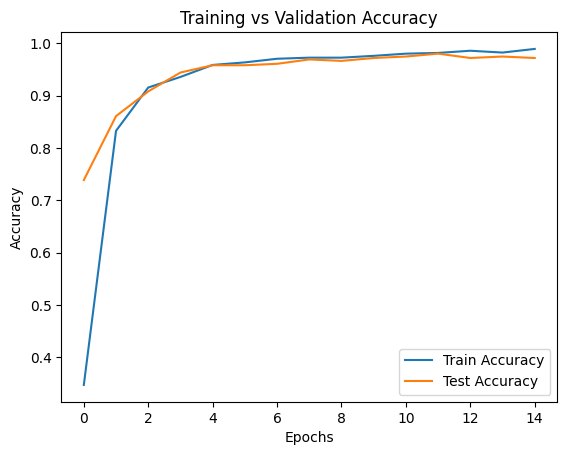

In [13]:
# Step 14: Visualizing Accuracy Curve
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

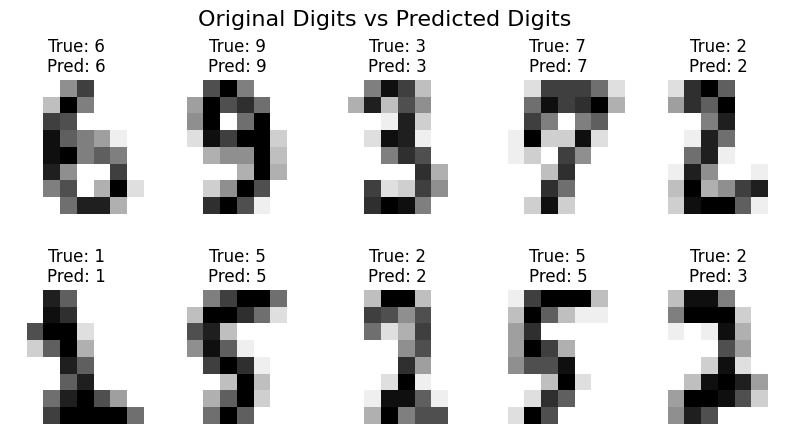

In [14]:
# Step 15: Visualizing Original vs Predicted Digits
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(8, 8), cmap='binary')
    ax.set_title(f"True: {y_true[i]}\nPred: {y_pred[i]}")
    ax.axis('off')
plt.suptitle("Original Digits vs Predicted Digits", fontsize=16)
plt.show()